# **Import needed libraries**

In [38]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adamax
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image
import warnings
warnings.filterwarnings('ignore')


# **Load Data**


In [ ]:
import os
from tqdm import tqdm

# Définir le chemin correct du dossier d'entraînement
train_dir = r"/content/data/Training"

filepaths = []
labels = []

# Vérifier si le dossier existe
if os.path.exists(train_dir):
    folds = os.listdir(train_dir)  # Utiliser train_dir au lieu de Train_df
    for fold in folds:
        FoldPath = os.path.join(train_dir, fold)  # Chemin complet de chaque dossier de catégorie
        if os.path.isdir(FoldPath):  # Vérifier que c'est un dossier et non un fichier
            files = os.listdir(FoldPath)
            for file in tqdm(files):
                filepath = os.path.join(FoldPath, file)
                filepaths.append(filepath)
                labels.append(fold)
    print("✅ Les chemins ont été chargés avec succès !")
else:
    print(f"❌ Erreur : Le dossier '{train_dir}' n'existe pas ! Assurez-vous que les données sont chargées correctement.")

100%|██████████| 1339/1339 [00:00<00:00, 617297.54it/s]

✅ تم تحميل المسارات بنجاح!


In [40]:
print(len(filepaths))
print(len(labels))


5712
5712


In [43]:
print(labels[-1])


meningioma


In [44]:
print(np.unique(labels))

['glioma' 'meningioma' 'notumor' 'pituitary']


In [45]:
df_train = pd.DataFrame(
    data = {
        'filepath': filepaths,
        'label': labels
    }
)

In [46]:
df_train.head()

,filepath,label
0,/content/data/Training/notumor/Tr-no_0547.jpg,notumor
1,/content/data/Training/notumor/Tr-no_0328.jpg,notumor
2,/content/data/Training/notumor/Tr-no_0550.jpg,notumor
3,/content/data/Training/notumor/Tr-no_1076.jpg,notumor
4,/content/data/Training/notumor/Tr-no_0776.jpg,notumor


In [47]:
color = ['#9AA6B2','#BCCCDC','#D9EAFD','#F8FAFC']

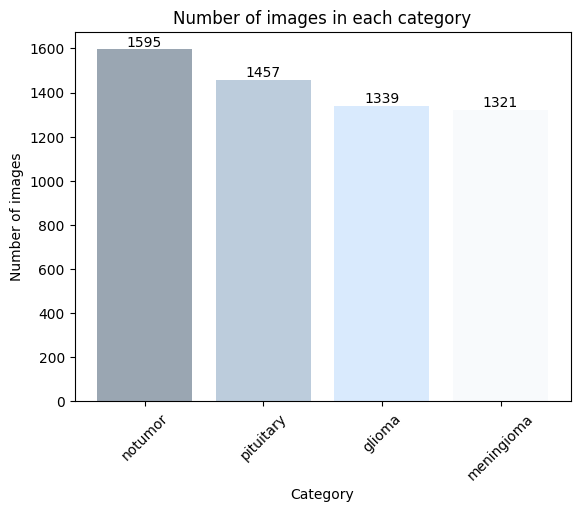

In [48]:

fig, ax = plt.subplots()
bars = ax.bar(df_train['label'].unique(), df_train['label'].value_counts(),color=color)
ax.bar_label(bars)
plt.title('Number of images in each category')
plt.xlabel('Category')
plt.ylabel('Number of images')
plt.xticks(rotation=45)

plt.show()


In [49]:
df_train.sample(5)

,filepath,label
3189,/content/data/Training/glioma/Tr-gl_0049.jpg,glioma
3519,/content/data/Training/glioma/Tr-gl_0815.jpg,glioma
3768,/content/data/Training/glioma/Tr-gl_1043.jpg,glioma
3148,/content/data/Training/glioma/Tr-gl_1205.jpg,glioma
4350,/content/data/Training/glioma/Tr-gl_0347.jpg,glioma


In [ ]:
test_dir = r"/content/data/Testing"

filepaths = []
labels = []

folds = os.listdir(test_dir)  
for fold in folds:
    FoldPath = os.path.join(test_dir, fold) 
    if os.path.isdir(FoldPath):  
        files = os.listdir(FoldPath)
        for file in tqdm(files):
            filepath = os.path.join(FoldPath, file)
            filepaths.append(filepath)
            labels.append(fold)


100%|██████████| 306/306 [00:00<00:00, 514411.63it/s]


In [51]:
print(len(filepaths))
print(len(labels))


1311
1311


In [52]:
print(np.unique(labels))

['glioma' 'meningioma' 'notumor' 'pituitary']


In [53]:
 df_test = pd.DataFrame(
    data = {
        'filepath': filepaths,
        'label': labels
    }
)

In [54]:
df_test.head()

,filepath,label
0,/content/data/Testing/notumor/Te-no_0343.jpg,notumor
1,/content/data/Testing/notumor/Te-no_0308.jpg,notumor
2,/content/data/Testing/notumor/Te-no_0159.jpg,notumor
3,/content/data/Testing/notumor/Te-no_0338.jpg,notumor
4,/content/data/Testing/notumor/Te-no_0231.jpg,notumor


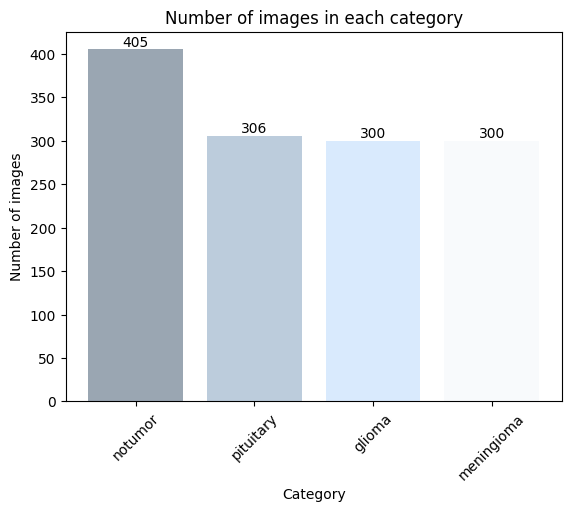

In [55]:

fig, ax = plt.subplots()
bars = ax.bar(df_test['label'].unique(), df_test['label'].value_counts(),color=color)
ax.bar_label(bars)
plt.title('Number of images in each category')
plt.xlabel('Category')
plt.ylabel('Number of images')
plt.xticks(rotation=45)

plt.show()


# **Split data into train, test, valid**

In [56]:
valid_ts, df_test = train_test_split(df_test, test_size=0.5, random_state=42)

In [57]:
tr_gen = ImageDataGenerator(rescale=1/255)
ts_gen = ImageDataGenerator(rescale=1/255)
batchsize = 32
img_size = (224,224)

In [58]:
gen_train = tr_gen.flow_from_dataframe(df_train, x_col='filepath', y_col='label', target_size=img_size, class_mode='categorical', batch_size=batchsize, shuffle=True,color_mode='rgb')
gen_valid = ts_gen.flow_from_dataframe(valid_ts, x_col='filepath', y_col='label', target_size=img_size, class_mode='categorical', batch_size=batchsize, shuffle=True,color_mode='rgb')
gen_test = ts_gen.flow_from_dataframe(df_test, x_col='filepath', y_col='label', target_size=img_size, class_mode='categorical', batch_size=batchsize, shuffle=False ,color_mode='rgb')

Found 5712 validated image filenames belonging to 4 classes.
Found 655 validated image filenames belonging to 4 classes.
Found 656 validated image filenames belonging to 4 classes.


In [59]:
class_dict = gen_train.class_indices


# **Building Deep Learning Model¶**

In [60]:

Model = Sequential([
    Conv2D(64, kernel_size= (3,3), activation='relu', input_shape=(img_size[0],img_size[1],3)),
    Conv2D(64, kernel_size= (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, kernel_size= (3,3), activation='relu'),
    Conv2D(128, kernel_size= (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(265, kernel_size= (3,3), activation='relu'),
    Conv2D(265, kernel_size= (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(512, kernel_size= (3,3), activation='relu'),
    Conv2D(512, kernel_size= (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(512, kernel_size= (3,3), activation='relu'),
    Conv2D(512, kernel_size= (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dense(64, activation='relu'),
    Dropout(0,3),
    Dense(4, activation='softmax') ])

In [61]:
Model.compile(optimizer=Adamax(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

In [62]:
history = Model.fit(
    gen_train,
    epochs=50,
    validation_data=gen_valid,
    verbose=1,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
)


Epoch 1/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 135s 566ms/step - accuracy: 0.4395 - loss: 1.1569 - val_accuracy: 0.6702 - val_loss: 0.8001
Epoch 2/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 75s 358ms/step - accuracy: 0.7243 - loss: 0.6991 - val_accuracy: 0.7527 - val_loss: 0.6312
Epoch 3/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 65s 363ms/step - accuracy: 0.8302 - loss: 0.4463 - val_accuracy: 0.7924 - val_loss: 0.5335
Epoch 4/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 66s 367ms/step - accuracy: 0.8688 - loss: 0.3524 - val_accuracy: 0.8489 - val_loss: 0.3960
Epoch 5/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 66s 369ms/step - accuracy: 0.8904 - loss: 0.2995 - val_accuracy: 0.8901 - val_loss: 0.3159
Epoch 6/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 66s 371ms/step - accuracy: 0.9133 - loss: 0.2336 - val_accuracy: 0.8977 - val_loss: 0.2462
Epoch 7/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 66s 371ms/step - accuracy: 0.9301 - loss: 0.1813 - val_accuracy: 0.8702 - val_loss: 0.3659
Epoch 8/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 66s 371ms/step - accuracy: 0.9417 - loss: 

In [64]:
print(Model.evaluate(gen_train))
print(Model.evaluate(gen_valid))
print(Model.evaluate(gen_test))

179/179 ━━━━━━━━━━━━━━━━━━━━ 28s 156ms/step - accuracy: 0.9985 - loss: 0.0068
[0.005845797713845968, 0.9985994100570679]
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - accuracy: 0.9758 - loss: 0.0803
[0.0889061763882637, 0.9725190997123718]
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.9711 - loss: 0.1505
[0.126870259642601, 0.9710366129875183]


In [ ]:
Model.save('/content/Model_m1.h5')
print("✅ Le modèle a été enregistré avec succès dans /content/Model_m.h5")


✅ تم حفظ النموذج بنجاح في /content/Model_m.h5


In [66]:
preds = Model.predict(gen_test)
y_pred = np.argmax(preds, axis=1)


21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 141ms/step


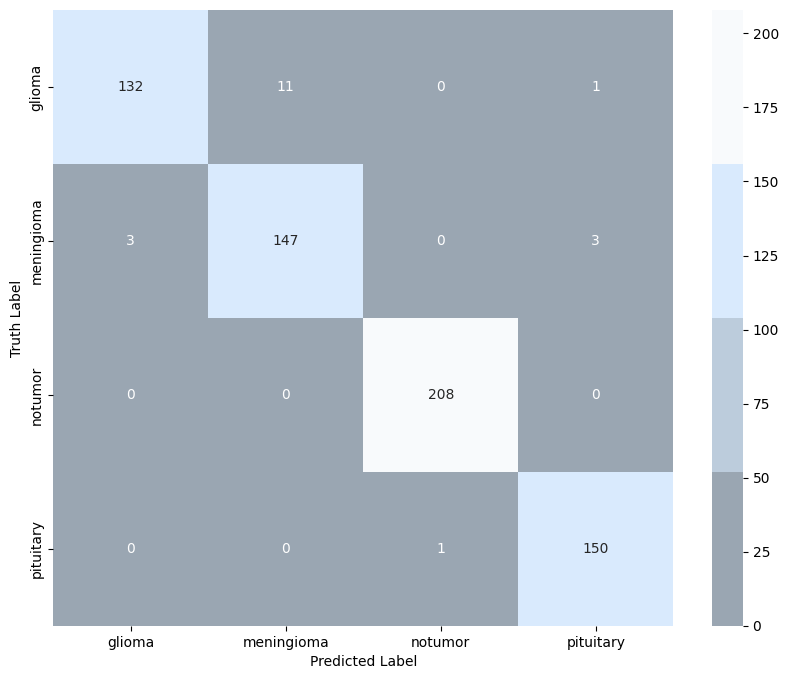

In [67]:
cm = confusion_matrix(gen_test.classes, y_pred)
labels = list(class_dict.keys())
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap=color, xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('Truth Label')
plt.show()

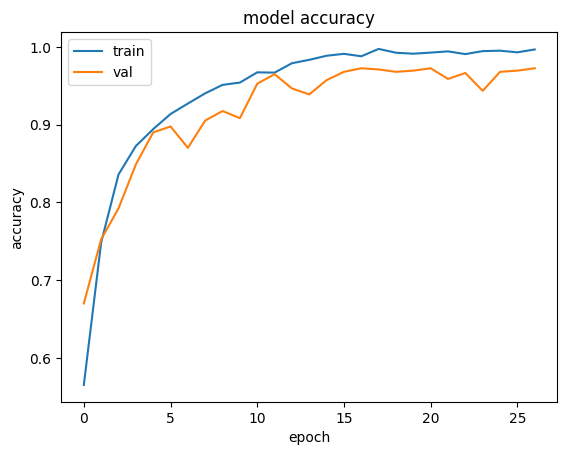

In [68]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

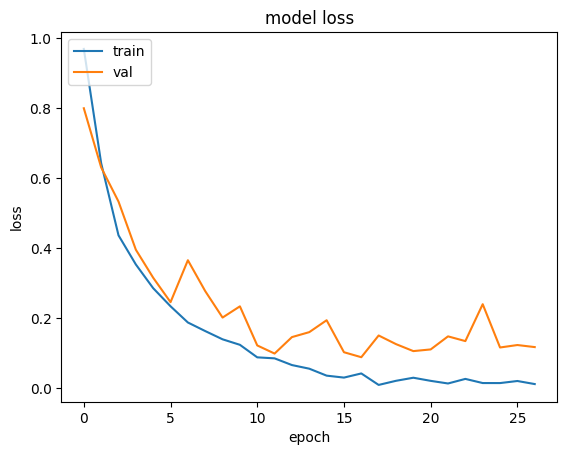

In [69]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

Visualize model performance

In [70]:
def predict(img_path):


    label = list(class_dict.keys())
    plt.figure(figsize=(12, 12))
    img = Image.open(img_path)
    resized_img = img.resize((224, 224))
    img = np.asarray(resized_img)
    img = np.expand_dims(img, axis=0)
    img = img / 255
    predictions = Model.predict(img)
    probs = list(predictions[0])
    labels = label
    plt.subplot(2, 1, 1)
    plt.imshow(resized_img)
    plt.subplot(2, 1, 2)
    bars = plt.barh(labels, probs)
    plt.xlabel('Probability', fontsize=15)
    ax = plt.gca()
    ax.bar_label(bars, fmt = '%.2f')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


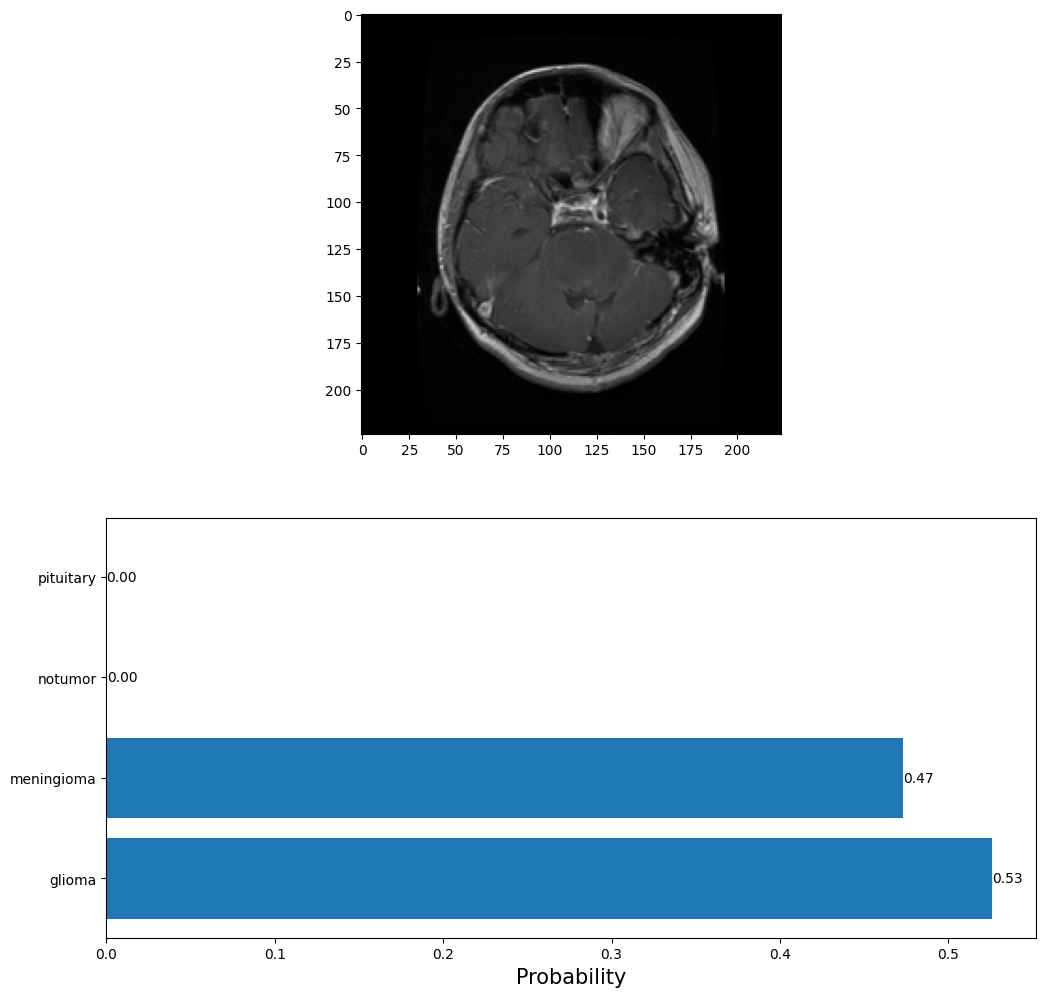

In [79]:
predict('/content/data/Testing/glioma/Te-gl_0010.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


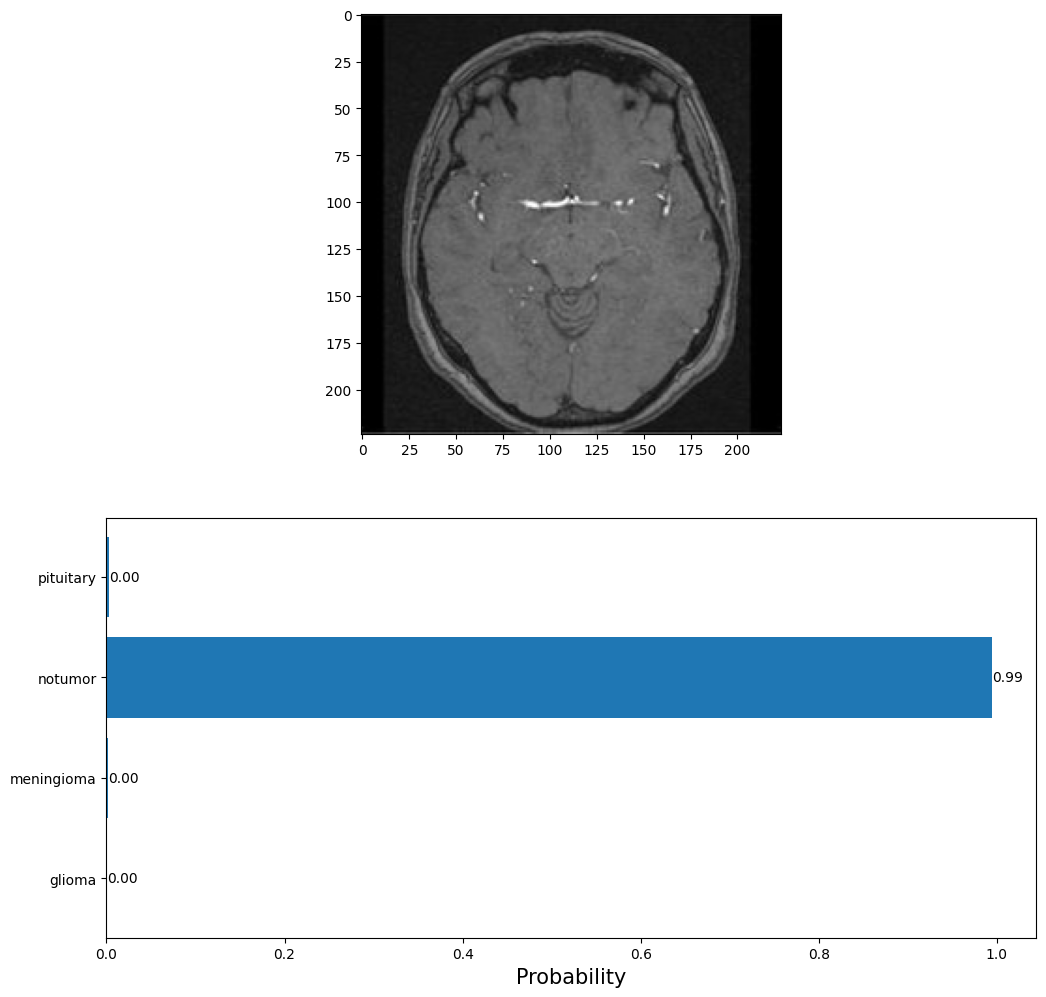

In [72]:
predict('/content/data/Testing/notumor/Te-no_0017.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


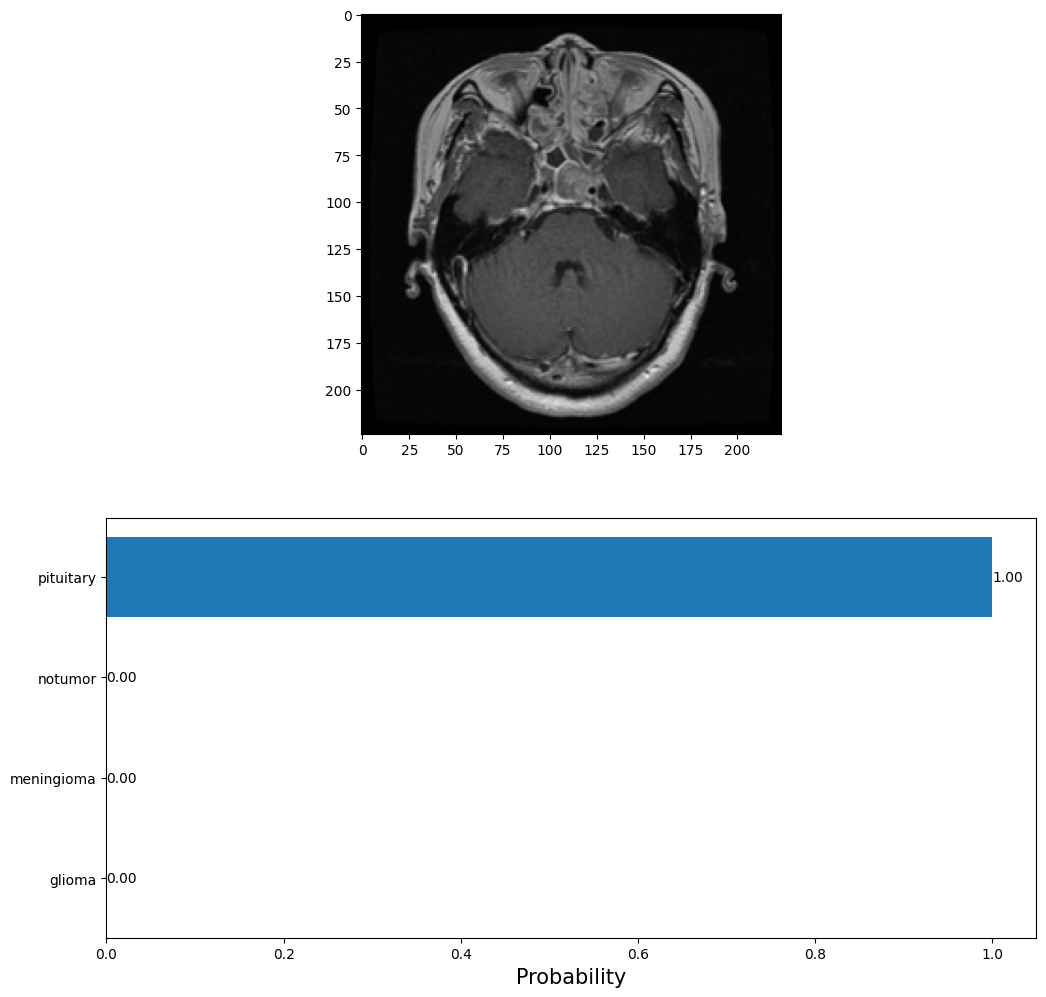

In [75]:
predict('/content/data/Testing/pituitary/Te-pi_0059.jpg')

 # **NOTE** : --> It is clear that there is overfitting, so I will use a pretrained model.

In [76]:
base_model = tf.keras.applications.EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_shape=(img_size[0],img_size[1],3),
    pooling='max',
)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
ModelPretrained = Sequential([
    base_model,

    Dense(256 , activation='relu'),
    Dropout(0,3),
    Dense(4, activation='softmax')

])
ModelPretrained.compile(optimizer=Adamax(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:
history_Final = ModelPretrained.fit(
    gen_train,
    epochs=5,
    validation_data=gen_valid,
    verbose=1,

)


Epoch 1/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 174s 500ms/step - accuracy: 0.7641 - loss: 1.8337 - val_accuracy: 0.2626 - val_loss: 1.5665
Epoch 2/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 41s 226ms/step - accuracy: 0.9635 - loss: 0.1060 - val_accuracy: 0.3221 - val_loss: 1.6735
Epoch 3/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 41s 225ms/step - accuracy: 0.9854 - loss: 0.0478 - val_accuracy: 0.6046 - val_loss: 1.0989
Epoch 4/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 41s 226ms/step - accuracy: 0.9901 - loss: 0.0264 - val_accuracy: 0.8534 - val_loss: 0.5403
Epoch 5/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 41s 227ms/step - accuracy: 0.9947 - loss: 0.0178 - val_accuracy: 0.9817 - val_loss: 0.0491


# **Testing and Evaluation**


In [ ]:
train_score = ModelPretrained.evaluate(gen_train, verbose=1)
valid_score = ModelPretrained.evaluate(gen_valid, verbose=1)
test_score = ModelPretrained.evaluate(gen_test, verbose=1)

print(f"Train Loss: {train_score[0]:.4f}")
print(f"Train Accuracy: {train_score[1]*100:.2f}%")
print('-' * 20)
print(f"Validation Loss: {valid_score[0]:.4f}")
print(f"Validation Accuracy: {valid_score[1]*100:.2f}%")
print('-' * 20)
print(f"Test Loss: {test_score[0]:.4f}")
print(f"Test Accuracy: {test_score[1]*100:.2f}%")

179/179 ━━━━━━━━━━━━━━━━━━━━ 17s 96ms/step - accuracy: 0.9993 - loss: 0.0048
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.9782 - loss: 0.0570
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.9936 - loss: 0.0200
Train Loss: 0.0048
Train Accuracy: 99.93%
--------------------
Validation Loss: 0.0491
Validation Accuracy: 98.17%
--------------------
Test Loss: 0.0167
Test Accuracy: 99.54%


In [ ]:
ModelPretrained.save('Model Final Brain Tumor.h5')

# **Visualize model performance**

In [ ]:
preds = ModelPretrained.predict(gen_test)
y_pred = np.argmax(preds, axis=1)


21/21 ━━━━━━━━━━━━━━━━━━━━ 16s 420ms/step


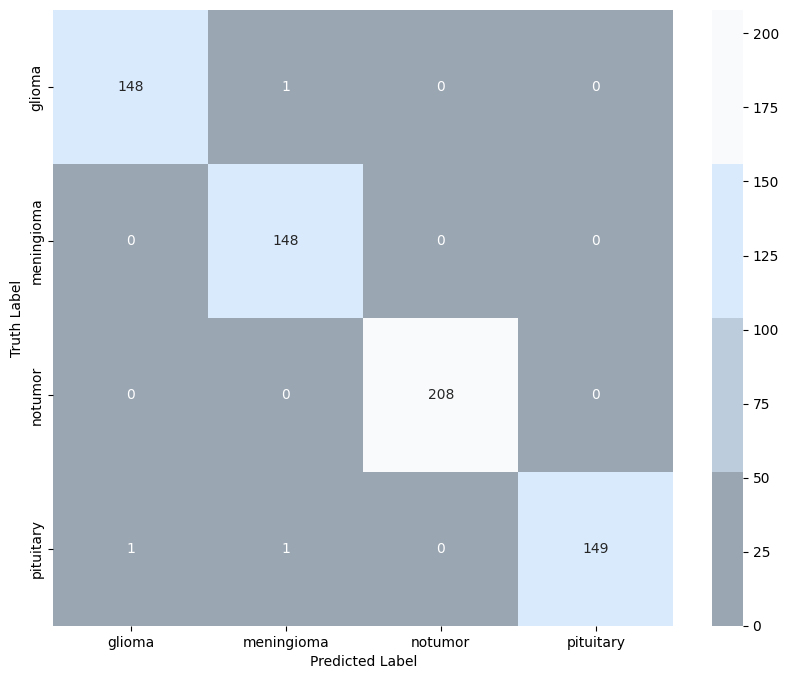

In [ ]:
cm = confusion_matrix(gen_test.classes, y_pred)
labels = list(class_dict.keys())
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap=color, xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('Truth Label')
plt.show()

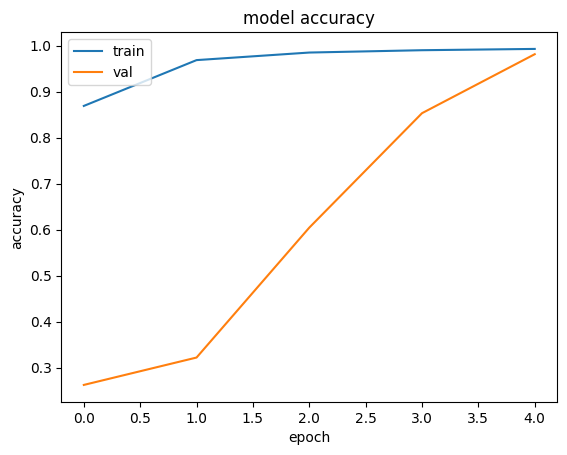

In [ ]:
plt.plot(history_Final.history['accuracy'])
plt.plot(history_Final.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

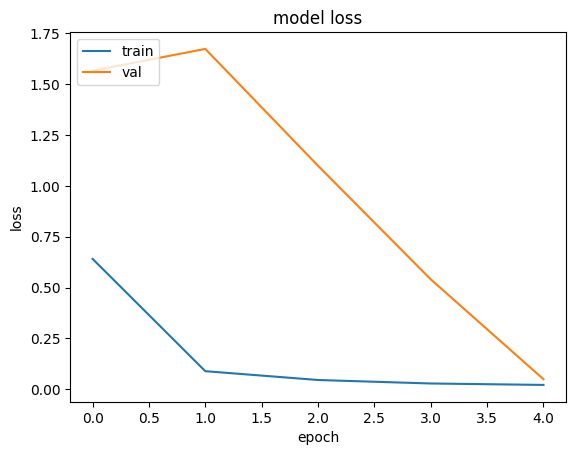

In [ ]:
plt.plot(history_Final.history['loss'])
plt.plot(history_Final.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

In [ ]:
def predict(img_path):


    label = list(class_dict.keys())
    plt.figure(figsize=(12, 12))
    img = Image.open(img_path)
    resized_img = img.resize((224, 224))
    img = np.asarray(resized_img)
    img = np.expand_dims(img, axis=0)
    img = img / 255
    predictions = ModelPretrained.predict(img)
    probs = list(predictions[0])
    labels = label
    plt.subplot(2, 1, 1)
    plt.imshow(resized_img)
    plt.subplot(2, 1, 2)
    bars = plt.barh(labels, probs)
    plt.xlabel('Probability', fontsize=15)
    ax = plt.gca()
    ax.bar_label(bars, fmt = '%.2f')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


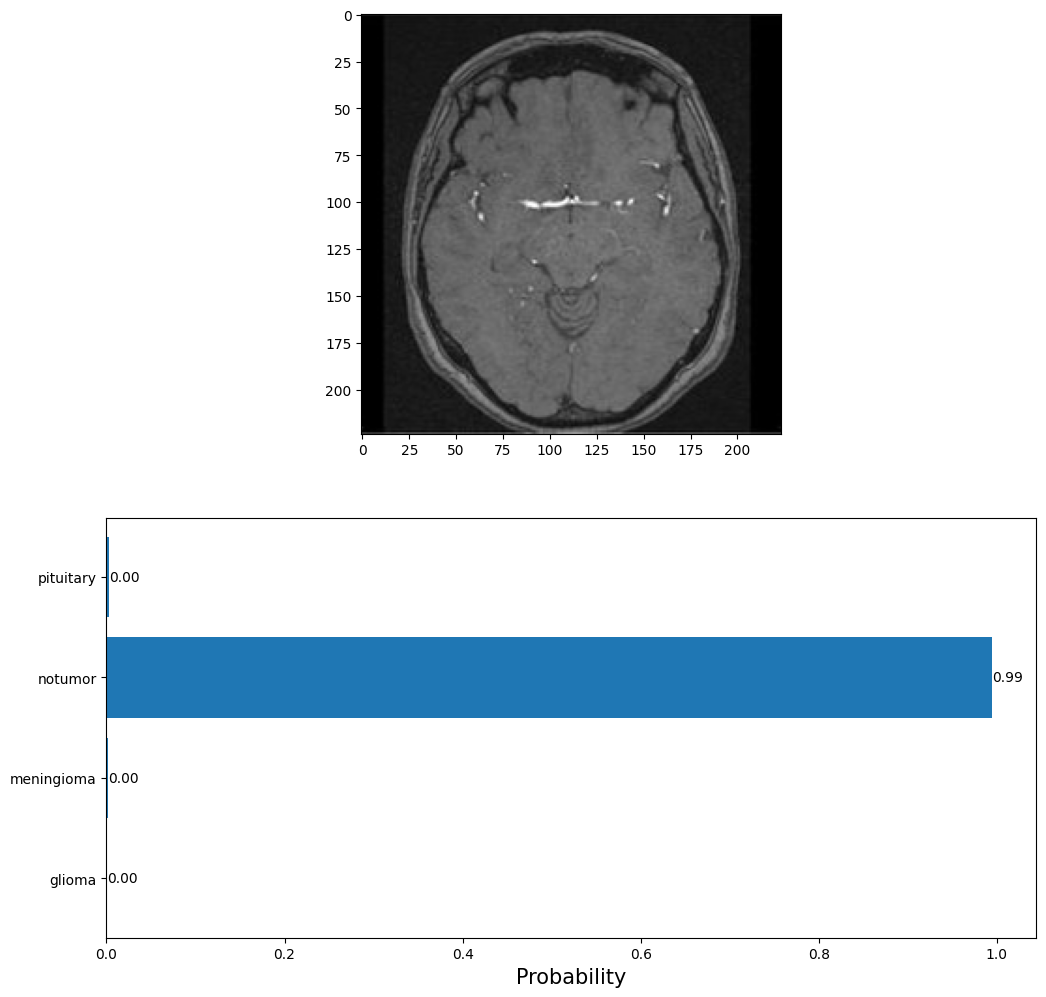

In [77]:
predict('/content/data/Testing/notumor/Te-no_0017.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


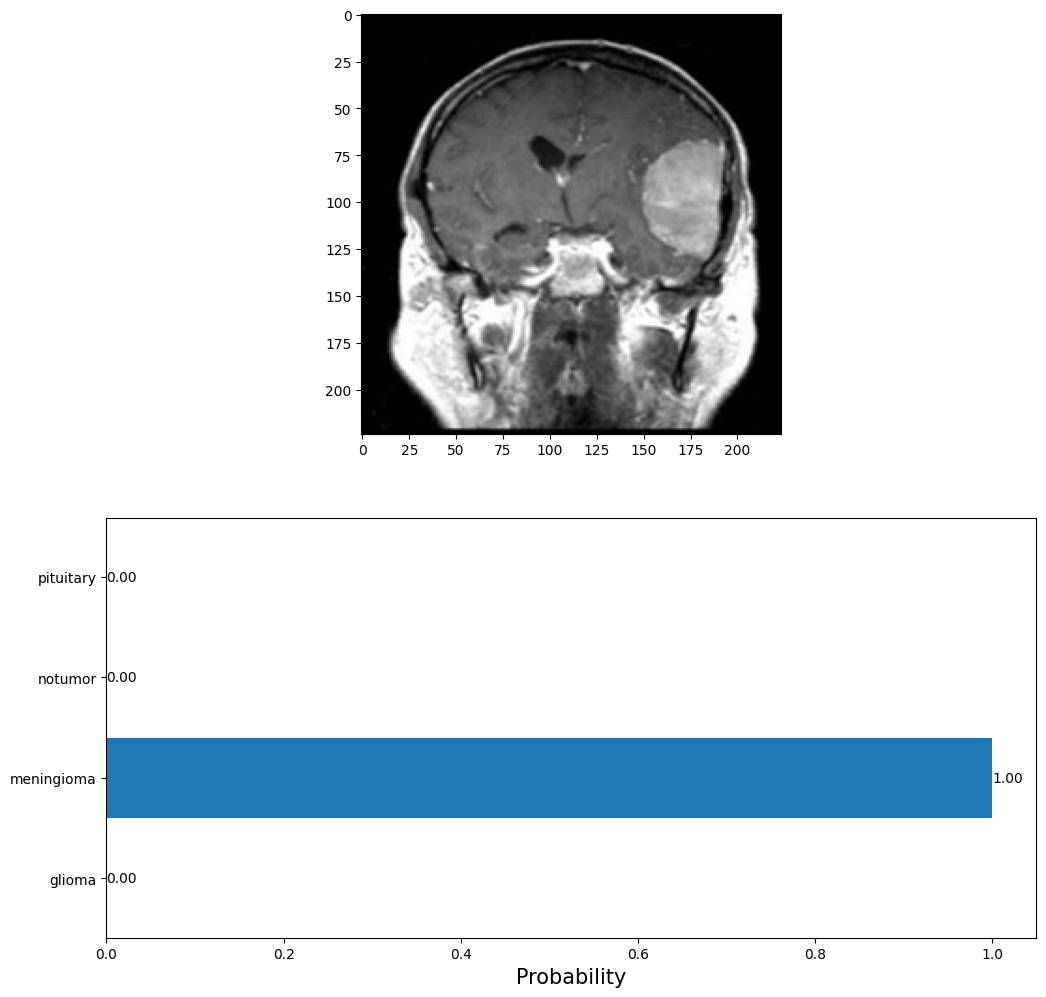

In [78]:
predict('/content/data/Testing/meningioma/Te-me_0016.jpg')